# Computer and Robot Vision - Kalman Filter

Here we import the dependencies:

In [66]:
import numpy as np
from typing import NamedTuple
import sympy
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# serve per montare Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Fill out the following information:

In [67]:
name = "Oleksandra"
surname = "Golub"
mat = "856706"

In [68]:
print(name, " ", surname, " ", mat, " ")

Oleksandra   Golub   856706  


## Parameters configuration

Here we setup a dataclass representing the robot and camera configuration and one representing the kalman states

In [69]:
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

class Scene(NamedTuple):
    baseline : float
    focal_length : float
    camera_height : float
    p2p_distance : float

class KalmanState(NamedTuple):
    state : np.ndarray
    cov : np.ndarray

    @property
    def x(self):
        return self.state[0]
    @x.setter
    def x(self, value):
        self.state[0] = value

    @property
    def y(self):
        return self.state[1]
    @y.setter
    def y(self, value):
        self.state[1] = value

    @property
    def theta(self):
        return self.state[2]
    @theta.setter
    def theta(self, value):
        self.state[2] = value

# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

In [70]:
## README: questo codice serviva a me per usare il file simulated_data.txt che ho caricato sul mio Google Drive
## nella consegna l'ho commentato, ma nel caso vi servisse per testare il codice, basta de-commentare questo blocco di codice
## e creare in un vostro Google Drive la cartella assignment_1_robot_and_computer_vision + mettere dentro il file di simulated_data.txt
## alla fine si commenta nel blocco sotto la riga di data = np.loadtxt('simulated_data.txt', delimiter=';')

## percorso del file su Google Drive
#path = '/content/drive/MyDrive/assignment_1_robot_and_computer_vision/simulated_data.txt'

## caricamento dei dati
#data = np.loadtxt(path, delimiter=';')

In [71]:
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

data = np.loadtxt('simulated_data.txt', delimiter=';')
odometry = data[:, 2:4]
camera_readings = data[:, 10:14]

steps = data.shape[0]
kalmanstates = []
predictions = []

# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

In [72]:
# ⬇️⬇️⬇️⬇️⬇️ COMPLETE THE CODE ⬇️⬇️⬇️⬇️⬇️
# Complete with the parameters of the scene
scene = Scene(
    baseline = 0.5,         # [m], the distance between the contact points of the wheels (0.5m)
    focal_length = 600,     # [pixel], the focal length of the camera (600pix)
    camera_height = 10,     # [m], the distance between the camera and the world plane (10m)
    p2p_distance = 0.6,     # [m], the distance between the two observed points on the robot (0.6m forward)
)

######
######

# Complete with the initial state estimate of the initial state
# and the covariance of the initial state estimate.
# The covariance matrix is a 3 by 3 matrix. Could it be diagonal?
# Include your reasoning in a comment or a text block.

## MIA RISPOSTA: la matrice di covarianza può essere diagonale perché all'inizio
## assumiamo che le incertezze sulle tre componenti dello stato (x, y, theta)
## siano indipendenti tra loro; non c'è correlazione iniziale tra posizione e orientamento.

# e.g.
#kalmanstates.append(KalmanState(
#     state = np.array([0.0, 0.0, 0.0]),  ## stato iniziale ovvero origine con orientamento 0
#     cov = np.array([
#         [1.0, 0.0, 0.0],  ## si ha un'incertezza elevata di 1.0 m^2 (varianza) ovvero 1m (dev std)
#         [0.0, 1.0, 0.0],  ## si ha un'incertezza elevata di 1.0 m^2 (varianza) ovvero 1m (dev std)
#         [0.0, 0.0, 1.0],  ## si ha un'incertezza elevata di 1.0 rad^2 (varianza) ovvero 1.0 rad che sono 57° (dev std)
#     ])
#))

kalmanstates.append(KalmanState(
     state = np.array([0.0, 0.0, 0.0]),  # stato iniziale ovvero origine con orientamento 0
     cov = np.array([
         [0.1, 0.0, 0.0],   # si ha un'incertezza moderata di 0.1 m^2 (varianza) ovvero 0.32m (dev std)
         [0.0, 0.1, 0.0],   # si ha un'incertezza moderata di 0.1 m^2 (varianza) ovvero 0.32m (dev std)
         [0.0, 0.0, 0.05],  # si ha un'incertezza moderata di 0.05 rad^2 (varianza) ovvero 0.22 rad che sono 13° (dev std)
     ])
))

## CONCLUSIONE su valori scelti sopra:
## si vede che il robot parte da una posizione conosciuta (punto di partenza segnato in [0.0, 0.0, 0.0])
## quindi, se il robot parte da un punto noto, l'incertezza iniziale deve essere piccola

## MA con cov = 1.0 dell'esempio, non so dove sia il robot, potrebbe essere ovunque in un raggio di 1 metro!
## pero con cov = 0.1, il robot è circa qui, con incertezza moderata di ~30 cm, percio' la situazione e' molto migliorata!

## invece, con 57° di incertezza non si capisce in che direzione il robot guarda!
## i 13° sembra un valore molto piu' ragionevole, almeno cosi' si capisce in che direzione guarda il robot

## in conclusione, con diag([1.0, 1.0, 1.0]) il filtro converge molto piu' lentamente (con piu' step) rispetto al filtro con diag([0.1, 0.1, 0.05]) (con meno step)

######
######

# Complete with the covariance of noises acting on the state and the mesure
# The covariance of the noise acting on the state is a 3 by 3 matrix, Could it be diagonal?
# The covariance of the noise acting on the measure is a 4 by 4 matrix, Could it be block diagonal?
# Include your reasoning in a comment or a text block.

## R: covarianza rumore di stato, 3x3 (rumore su x, su y, su theta)
## R in EKF (extended kalman filter) dice quanto mi fido (tramite l'incertezza) del modello di moto (odometria)

## MIA RISPOSTA: può essere diagonale perché assumiamo che gli errori odometrici
## si propaghino indipendentemente lungo x, y e theta. Gli errori su x e y
## derivano principalmente da slip e imprecisioni nella misura degli archi,
## mentre l'errore su theta deriva da differenze negli archi delle due ruote;
## non c'è correlazione diretta tra questi errori.

# e.g.
#R = [
#     [1.0, 0.0, 0.0],  # varianza errore su x
#     [0.0, 1.0, 0.0],  # varianza errore su y
#     [0.0, 0.0, 1.0],  # varianza errore su theta
#]

## CONCLUSIONE su R: questa R non vada bene, perche' ha valori troppo grandi

######
######

## Q: covarianza rumore di misura (camera), 4x4 (due coordinate pixel del punto P1 e poi due su P2, quindi rumori su u1, v1, u2, v2)
## Q in EKF (extended kalman filter) dice quanto mi fido del sensore (camera)

## MIA RISPOSTA: può essere diagonale (non necessariamente block-diagonal, 2x2)
## perché assumiamo che gli errori di misura su ciascuna coordinata pixel
## (u1, v1, u2, v2) siano indipendenti; anche se le misure si riferiscono
## a due punti distinti (P1 e P2), gli errori di quantizzazione e rumore
## del sensore sono tipicamente non correlati tra le diverse coordinate
## (perché la correlazione dipende dal sensore, non dalla geometria del robot).

## da notare che EKF funziona sia con Q diagonale che con Q block-diagonal

## quindi, se volessimo modellare una correlazione tra le coordinate dello stesso punto
## (per esempio: u1 e v1 correlate), potremmo usare una struttura block-diagonal:
## Q_block_P1 = [[σ^2_P1,  ρ],        dove ogni blocco 2x2 rappresenta la covarianza di un punto
##              [ρ,       σ^2_P1]]    (perciò lo stesso ragionamento vale per P2),
## ma per semplicità e data l'indipendenza del rumore pixel, usiamo diagonale!

# e.g.
#Q = [
#     [0.5, 0.5, 0.0, 0.0],  # varianza errore su u1 (~2 pixel)
#     [0.5, 0.5, 0.0, 0.0],  # varianza errore su v1 (~2 pixel)
#     [0.0, 0.0, 0.5, 0.5],  # varianza errore su u2 (~2 pixel)
#     [0.0, 0.0, 0.5, 0.5],  # varianza errore su v2 (~2 pixel)
#]

## CONCLUSIONE su Q: questa Q non vada bene, perche' non e' diagonale e 0.5 sembra un valore troppo piccolo

######
######

## ad ogni step, l'odometria introduce rumore dell’ordine di 10 cm su x e y (sqrt(0.01) ≈ 0.1 m) + circa 4° di theta (sqrt(0.005) circa 0.07rad circa 4°) sull’orientamento
R = np.diag([0.01, 0.01, 0.005])
## qua i valori indicano una varianza di 2 pixel^2 per ciascuna coordinata (u1, v1, u2, v2), corrispondente a una deviazione standard di circa sqrt(2) (che vale circa 1.4 pixel)
Q = np.diag([2.0, 2.0, 2.0, 2.0])

## CONCLUSIONI FINALI SUI VALORI SCELTI DI R E Q:
## se usassimo R e Q dell'esempio, avremmo ellissi enorme con 1 metro di incertezza,
## invece con valori che ho scelto, si hanno ellissi piu' piccole di circa 30 cm di incertezza

# ⬆️⬆️⬆️⬆️⬆️ COMPLETE THE CODE ⬆️⬆️⬆️⬆️⬆️

# State equations

Here we define the functions H and G using symbolic computations with the package SymPy


In [73]:
# ⬇️⬇️⬇️⬇️⬇️ COMPLETE THE CODE ⬇️⬇️⬇️⬇️⬇️
def symbolicH():
    focal, x, y, theta, p2p_distance, camera_height = sympy.symbols('f x y theta d h')

    # Define the four vector components using the symbolic variables.
    # Keep in mind that, while basic operators are supported by sympy,
    # if you need a particular function (e.g. trig functions)
    # you should use the sympy version and not the numpy version.
    # e.g.
    # u1 = x + sympy.tan(y) / x

    ## punto P1 coincide con l’origine del robot nel mondo (x, y), mentre la camera
    ## proietta il punto sul piano immagine con proiezione prospettica: u = f*X/h, v = -f*Y/h (immagine)

    ## se il robot si sposta in x nel mondo, u1 cresce;
    ## se si sposta in y, v1 cambia con segno meno

    u1 = focal * x / camera_height
    v1 = -focal * y / camera_height

    ## punto P2 è un punto fissato sul robot a distanza d lungo l’asse x del robot
    ## la sua posizione nel mondo dipende da: posizione del robot e orientamento di theta
    ## per questo u2 e v2 dipendono anche da theta, a differenza di u1 e v1

    u2 = focal * (x + p2p_distance * sympy.cos(theta)) / camera_height
    v2 = -focal * (y + p2p_distance * sympy.sin(theta)) / camera_height

    ## jacobiana finale che serve per l'aggiornamento di EKF
    return sympy.Matrix([u1, v1, u2, v2]).jacobian(sympy.Matrix([x, y, theta]))

H = symbolicH()

H
# ⬆️⬆️⬆️⬆️⬆️ COMPLETE THE CODE ⬆️⬆️⬆️⬆️⬆️

Matrix([
[f/h,    0,                 0],
[  0, -f/h,                 0],
[f/h,    0, -d*f*sin(theta)/h],
[  0, -f/h, -d*f*cos(theta)/h]])

In [74]:
# ⬇️⬇️⬇️⬇️⬇️ COMPLETE THE CODE ⬇️⬇️⬇️⬇️⬇️
def symbolicG():
    x, y, theta, baseline, sdx, ssx, = sympy.symbols('x y theta b s_dx s_sx')

    # Define the G matrix using the symbolic variables.
    # Keep in mind that the analytical form depends on whether
    # the robot is moving in a straight line or not.

    ## per il movimento curvilineo (caso generale quando ssx è diverso da sdx, quindi il robot ruota),
    ## usiamo il modello di cinematica differenziale basato sul CIR (Centro Istantaneo Rotazione)

    ## calcolo parametri movimento (sdx e ssx sono gli archi percorsi dalle ruote)
    delta_theta = (ssx - sdx) / baseline # dice quanto ruota il robot nello step
    d = sdx * baseline / (ssx - sdx) # dice la distanza dal CIR

    ## modello di stato (movimento curvilineo) aggiornato
    ## serve per ottenere la rototraslazione lungo un arco
    ## cosi che il robot ruota di delta_theta attorno al CIR
    ## mentre x e y cambiano dato che si segue un arco, non una linea retta
    x_next = x - d * sympy.sin(theta) + d * sympy.sin(theta + delta_theta)
    y_next = y + d * sympy.cos(theta) - d * sympy.cos(theta + delta_theta)
    theta_next = theta + delta_theta

    ## vettore di stato che serve per predizione di EKF per propagare la covarianza
    g = sympy.Matrix([x_next, y_next, theta_next])

    ## jacobiana finale del moto che viene usata nella predizione di EKF
    return g.jacobian(sympy.Matrix([x, y, theta]))

G = symbolicG()

G
# ⬆️⬆️⬆️⬆️⬆️ COMPLETE THE CODE ⬆️⬆️⬆️⬆️⬆️

Matrix([
[1, 0, -b*s_dx*cos(theta)/(-s_dx + s_sx) + b*s_dx*cos(theta + (-s_dx + s_sx)/b)/(-s_dx + s_sx)],
[0, 1, -b*s_dx*sin(theta)/(-s_dx + s_sx) + b*s_dx*sin(theta + (-s_dx + s_sx)/b)/(-s_dx + s_sx)],
[0, 0,                                                                                       1]])

# Kalman filter functions

Here we define the functions dictating how prediction and filtering steps are performed

In [75]:
# ⬇️⬇️⬇️⬇️⬇️ COMPLETE THE CODE ⬇️⬇️⬇️⬇️⬇️
def predict_state(state, odometry, scene, G, R) -> KalmanState:
    # Compute the next state prediction.
    # Be sure to return the state as an np.ndarray of shape (3,)
    # and a covariance matrix as an np.ndarray of shape (3,3).

    ## si estraggono i componenti dello stato corrente
    x = state.x
    y = state.y
    theta = state.theta

    ## si estraggono le letture odometriche
    sdx = odometry[0]  # arco ruota destra
    ssx = odometry[1]  # arco ruota sinistra

    ## caso speciale: movimento rettilineo (ruote girano quasi uguale)
    if np.abs(ssx - sdx) < 1e-6:
        ## movimento rettilineo: il robot va dritto
        delta_s = (ssx + sdx) / 2.0

        ## predizione stato
        predicted_state_vector = np.array([
            x + delta_s * np.cos(theta),
            y + delta_s * np.sin(theta),
            theta  # orientamento non cambia
        ])

        ## jacobiano per movimento rettilineo
        G_straight = np.eye(3)
        G_straight[0, 2] = -delta_s * np.sin(theta)
        G_straight[1, 2] = delta_s * np.cos(theta)

        ## predizione covarianza nel caso rettilineo
        predicted_cov = G_straight @ state.cov @ G_straight.T + R

    else:
        ## caso generale: movimento curvilineo
        ## parametri movimento
        delta_theta = (ssx - sdx) / scene.baseline
        d = sdx * scene.baseline / (ssx - sdx)

        ## predizione dello stato usando cinematica differenziale
        predicted_state_vector = np.array([
            x - d * np.sin(theta) + d * np.sin(theta + delta_theta),
            y + d * np.cos(theta) - d * np.cos(theta + delta_theta),
            theta + delta_theta
        ])

        ## normalizzazione dell'angolo in [-π, π]
        ## serve per evitare crescita illimitata dell'angolo e mantenere stabilità numerica
        predicted_state_vector[2] = np.arctan2(
            np.sin(predicted_state_vector[2]),
            np.cos(predicted_state_vector[2])
        )

        ## G è già stato valutato numericamente dalla funzione execute_kalman_step nello step corrente
        ## predizione covarianza nel caso curvilineo
        predicted_cov = G @ state.cov @ G.T + R

    pred = KalmanState(
        state = predicted_state_vector,
        cov = predicted_cov
    )
    return pred

## decide quanto fidarsi della predizione e quanto della misura
def compute_gain(predicted_state_cov, H, Q):
    # Compute the filter gain.
    # Be sure to return an np.ndarray of shape (3, 4).

    ## formula per Kalman Gain: K = P_pred * H^T * (H * P_pred * H^T + Q)^-1
    return predicted_state_cov @ H.T @ (np.linalg.inv(H @ predicted_state_cov @ H.T + Q))

## calcola la misura prevista dalla posa predetta cioè dove dovrebbero cadere
## in pixel P1 e P2 se lo stato predetto fosse corretto
def predict_camera_reading(predicted_state, scene):
    # Compute the predicted camera reading.
    # Be sure to return an np.ndarray of shape (4,) and of form [u1, v1, u2, v2].
    return np.array([
         scene.focal_length * predicted_state.x / scene.camera_height,
        -scene.focal_length * predicted_state.y / scene.camera_height,
         scene.focal_length * (np.cos(predicted_state.theta) * scene.p2p_distance + predicted_state.x) / scene.camera_height,
        -scene.focal_length * (np.sin(predicted_state.theta) * scene.p2p_distance + predicted_state.y) / scene.camera_height,
    ])

def filter_state(predicted_state, camera_reading, predicted_camera_reading, K, H) -> KalmanState:
    # Compute the filtered state.
    # Be sure to return the state as an np.ndarray of shape (3,)
    # and a covariance matrix as an np.ndarray of shape (3,3).

    ## ora si effettua il measurement update ovvero correzione di EKF!

    ## si calcola l'innovazione della differenza tra misura reale e attesa
    innovation = camera_reading - predicted_camera_reading  # (4,)

    ## si corregge lo stato
    ## da notare che K ha shape (3, 4), innovation ha shape (4,)
    ## quindi come risultato si ha (3,)
    corrected_state_vector = predicted_state.state + K @ innovation

    ## si normalizza l'angolo in [-π, π]
    corrected_state_vector[2] = np.arctan2(
        np.sin(corrected_state_vector[2]),
        np.cos(corrected_state_vector[2])
    )

    ## si corregge la covarianza: P_filt = (I - K * H) * P_pred
    corrected_cov = (np.eye(3) - K @ H) @ predicted_state.cov

    filtered_state = KalmanState(
        state = corrected_state_vector,
        cov = corrected_cov
    )
    return filtered_state

# ⬆️⬆️⬆️⬆️⬆️ COMPLETE THE CODE ⬆️⬆️⬆️⬆️⬆️

# Execution

In [76]:
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑
def execute_kalman_step(state:KalmanState, odometry, camera_reading, scene, R, Q, G, H):
    x, y, theta, baseline, sdx, ssx, = sympy.symbols('x y theta b s_dx s_sx')
    G = np.array(G.subs([
        [x, state.x],
        [y, state.y],
        [theta, state.theta],
        [baseline, scene.baseline],
        [sdx, odometry[0]],
        [ssx, odometry[1]],
    ])).astype(np.float64)
    predicted_state = predict_state(state, odometry, scene, G, R)

    focal, x, y, theta, p2p_distance, camera_height = sympy.symbols('f x y theta d h')
    H = np.array(H.subs([
        [focal, scene.focal_length],
        [x, predicted_state.x],
        [y, predicted_state.y],
        [theta, predicted_state.theta],
        [p2p_distance, scene.p2p_distance],
        [camera_height, scene.camera_height],
    ])).astype(np.float64)

    K = compute_gain(predicted_state.cov, H, Q)
    expected_camera_reading = predict_camera_reading(predicted_state, scene)
    filtered_state = filter_state(predicted_state, camera_reading, expected_camera_reading, K, H)

    return filtered_state, predicted_state
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

In [77]:
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑
for i in range(steps-1):
    print(('Filtering step {:d}/{:d}; Current uncertainty (x,y,ang): {:0.6f} {:0.6f} {:0.6f}'.format(i, steps-1, kalmanstates[i].cov[0,0], kalmanstates[i].cov[1,1], kalmanstates[i].cov[2,2])))
    filtered_state, predicted_state = execute_kalman_step(
        kalmanstates[i],
        odometry[i, :],
        camera_readings[i, :],
        scene,
        R,
        Q,
        G,
        H,
    )
    kalmanstates.append(filtered_state)
    predictions.append(predicted_state)
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

Filtering step 0/265; Current uncertainty (x,y,ang): 0.100000 0.100000 0.050000
Filtering step 1/265; Current uncertainty (x,y,ang): 0.000278 0.000536 0.002904
Filtering step 2/265; Current uncertainty (x,y,ang): 0.000272 0.000457 0.002188
Filtering step 3/265; Current uncertainty (x,y,ang): 0.000272 0.000451 0.002128
Filtering step 4/265; Current uncertainty (x,y,ang): 0.000274 0.000449 0.002123
Filtering step 5/265; Current uncertainty (x,y,ang): 0.000270 0.000451 0.002117
Filtering step 6/265; Current uncertainty (x,y,ang): 0.000271 0.000451 0.002120
Filtering step 7/265; Current uncertainty (x,y,ang): 0.000271 0.000453 0.002125
Filtering step 8/265; Current uncertainty (x,y,ang): 0.000271 0.000452 0.002124
Filtering step 9/265; Current uncertainty (x,y,ang): 0.000271 0.000453 0.002124
Filtering step 10/265; Current uncertainty (x,y,ang): 0.000271 0.000451 0.002119
Filtering step 11/265; Current uncertainty (x,y,ang): 0.000272 0.000451 0.002122
Filtering step 12/265; Current uncerta

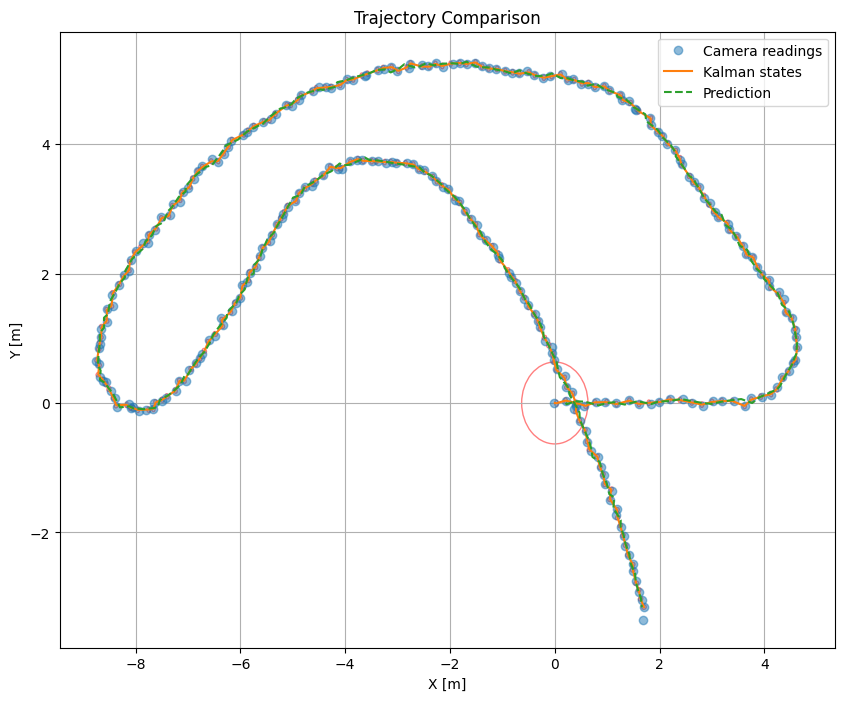

In [78]:
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑
def plot_cov_ellipse(cov, pos, nstd=2, ax=None, **kwargs):
    """
    Plots an ellipse representing the covariance matrix cov centered at pos.
    nstd: Number of standard deviations (default 2 for ~95% confidence).
    """
    if ax is None:
        ax = plt.gca()
    # Only take the position covariance (x, y)
    cov = cov[:2, :2]
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * nstd * np.sqrt(vals)
    ellip = Ellipse(xy=pos, width=width, height=height, angle=theta, **kwargs)
    ax.add_patch(ellip)

plt.figure(figsize=(10, 8))

kalmanstate = np.stack([ks.state for ks in kalmanstates], axis=0)
kalmanstatecov = np.stack([ks.cov for ks in kalmanstates], axis=-1)
prediction = np.stack([ks.state for ks in predictions], axis=0)

# 1. Camera readings (converted to world coordinates)
x_cam = camera_readings[:, 0] * scene.camera_height / scene.focal_length
y_cam = -camera_readings[:, 1] * scene.camera_height / scene.focal_length
plt.plot(x_cam, y_cam, 'o', label='Camera readings', alpha=0.5)

# 2. Kalman states
plt.plot(kalmanstate[:, 0], kalmanstate[:, 1], '-', label='Kalman states')

# 3. Prediction
plt.plot(prediction[:, 0], prediction[:, 1], '--', label='Prediction')

# Plot ellipses for each step (sparser for clarity)
for i in range(steps):
    plot_cov_ellipse(kalmanstatecov[:, :, i], kalmanstate[i, :2], nstd=2, ax=plt.gca(), edgecolor='r', facecolor='none', alpha=0.5)

plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.legend()
plt.title('Trajectory Comparison')
plt.grid(True)
plt.show()
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑